# Introduction

**Author:** Dr. Sur Herrera Paredes

This notebook walks through a complete workflow for building a relative-abundance bar plot for bacterial communities found in individual plants.

The main idea is simple: sequence counts are useful, but raw counts are not directly comparable across samples because library sizes can differ. Converting counts to **relative abundance** makes the samples easier to compare and helps highlight differences in community composition.

We will start with an OTU table, reshape it into a tidy format, select a few OTUs, normalize within each sample, and then visualize the results. In the second half of the notebook, we will merge sample metadata and taxonomy so we can compare communities across experimental conditions and at higher taxonomic levels.

The example uses data from a study published here: https://www.nature.com/articles/nature11237. In that experiment, individual *Arabidopsis thaliana* plants were grown in separate pots containing natural soils collected across seasons. Plants were sampled across accessions and developmental stages, which makes the dataset useful for showing both biological variation and data-visualization workflow.


If you haven't check the
[README](https://github.com/surh/scip_barplot/blob/master/README.md) file
of the GitHub repository of the workshop.

## Getting the data

First, download or mount the files used in the workshop. The notebook expects the OTU table, sample metadata, and taxonomy table to be available in the Google Drive path shown below.

The original workshop was written in R, so the Python version below keeps the same overall logic while using pandas, seaborn, and matplotlib.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn for nicer plots
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)

## Load data

Start by importing the libraries needed for data wrangling and plotting. Note you will need to have downloaded the data from the google doc instructions and may need to change the path location depending on how you have it organized. Then read the OTU table into a pandas DataFrame.

At this stage, we are still in **wide format**, where each sample is a column. That format is convenient for storage, but not ideal for most plotting tasks.

In [ ]:
# Load OTU table
from google.colab import drive
drive.mount('/content/drive')

tab = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/SCIP2026/UPDATED CURRICULUM/Python Track/Python2026/scip_data/Chapter5/MicrobiologyData/otu_table.tsv', sep="\t")


tab.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,otu_id,D1,D2,D3,D10,D57,D58,D86,D194,D195,D196,D197,D198,D214,D215,D216,D217,D218,D219,D220,D221,D222,D223,D224,D258,D259,D260,D272,D273,D274,D275,D276,D410,D411,D412,D413,D414,D415,D416,D417,D418,D419,D420,D421,D422,D423,D424,D425,D426,D427,D428,D429,D447,D448,D449,D450,D451,D452,D453,D454,D455,D456,D678,D679,D680,D681,D682,D1045,D1046,D1047
0,OTU_14834,39,66,56,125,4,18,7,0,5,1,1,8,2,7,1,3,0,3,0,4,0,2,2,75,51,74,78,79,71,50,38,0,1,0,3,0,1,3,4,2,1,3,6,0,3,6,6,5,10,5,11,5,12,5,3,4,3,6,7,2,13,8,0,9,11,2,8,5,3
1,OTU_18567,0,1,0,0,4,8,14,16,34,19,15,31,26,25,32,16,12,16,11,10,5,10,13,0,0,1,1,0,1,2,6,0,0,1,0,0,0,1,0,0,0,0,0,1,3,1,2,1,0,1,0,2,1,2,8,4,5,1,0,1,1,15,45,7,8,3,6,11,7
2,OTU_14402,10,27,32,45,2,4,4,0,1,0,0,2,0,2,1,2,0,0,0,0,0,1,0,10,1,8,41,23,40,27,8,0,0,0,0,1,0,0,1,0,1,1,1,0,1,2,2,0,1,1,0,1,1,0,1,0,0,2,1,1,4,6,1,0,1,0,3,1,3
3,OTU_14822,0,0,0,0,0,0,0,9,7,11,11,8,13,16,9,14,12,16,12,10,14,12,15,0,0,0,0,0,0,0,1,7,7,5,3,5,5,8,10,8,7,3,9,5,6,8,1,2,5,8,2,2,6,5,10,4,10,6,4,6,2,0,0,0,0,0,0,0,1
4,OTU_16757,0,0,0,0,0,0,0,8,10,12,10,15,28,14,26,21,15,17,23,12,23,12,34,0,0,0,0,0,0,0,0,2,5,6,5,5,8,9,8,5,5,2,3,3,3,2,2,3,8,7,8,3,7,5,7,4,6,6,3,7,11,0,0,0,0,0,0,0,0


**What to expect:** after loading the OTU table, the first rows should show OTU IDs in the first column and one column per sample. This confirms that the input data were read correctly.

## Reshape data from wide to long format

Most plotting functions work better with **tidy** or **long** data, where each row represents one observation.

Here, `melt()` converts the OTU table so that we get one row per OTU-sample pair. This makes it easier to filter, group, summarize, and plot the data later.

In [ ]:
dat = tab.melt(id_vars="otu_id",
               var_name="sample_id",
               value_name="count")

dat.head()

,otu_id,sample_id,count
0,OTU_14834,D1,39
1,OTU_18567,D1,0
2,OTU_14402,D1,10
3,OTU_14822,D1,0
4,OTU_16757,D1,0


**Why this matters:** the melted table is the foundation for the rest of the workflow. From here on, each row is an OTU-sample observation that can be filtered or summarized easily.

## Subset the data

To keep the example readable, we select a small set of OTUs. This lets us focus on the plotting workflow without overwhelming the figure with too many categories.

In a real analysis, this step might be replaced with a biologically motivated filter such as the most abundant taxa or the taxa of a particular group.

In [ ]:
selected_otus = ["OTU_14834", "OTU_18567", "OTU_14402", "OTU_14822"]

dat_subset = dat[dat["otu_id"].isin(selected_otus)]

dat_subset.head()

,otu_id,sample_id,count
0,OTU_14834,D1,39
1,OTU_18567,D1,0
2,OTU_14402,D1,10
3,OTU_14822,D1,0
129,OTU_14834,D2,66


**Interpretation note:** the subset is intentionally small so the plots stay readable. The same logic would work for any number of OTUs.

## Normalize counts within each sample

Raw read counts are not directly comparable across samples because the total number of reads can differ from sample to sample.

To correct for that, we divide each OTU count by the total counts in its sample. The result is **relative abundance**, which is easier to compare across samples.

In [ ]:
# Make an explicit copy before assigning a new column to avoid SettingWithCopyWarning
dat_subset = dat_subset.copy()


dat_subset["rel_abundance"] = dat_subset.groupby("sample_id")["count"]\
                                        .transform(lambda x: x / x.sum())

/tmp/ipykernel_1372/1696278069.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat_subset["rel_abundance"] = dat_subset.groupby("sample_id")["count"]\


**Normalization check:** each sample now sums to 1 across the selected OTUs, so the y-axis can be interpreted as relative abundance rather than raw read count.

## Plot relative abundance by OTU

This first plot shows the selected OTUs separately for each sample. It is a quick way to check whether one OTU dominates or whether the community is more evenly distributed.

A few things to notice here:
- bar height reflects relative abundance
- color identifies the OTU
- the x-axis is rotated to keep sample labels readable

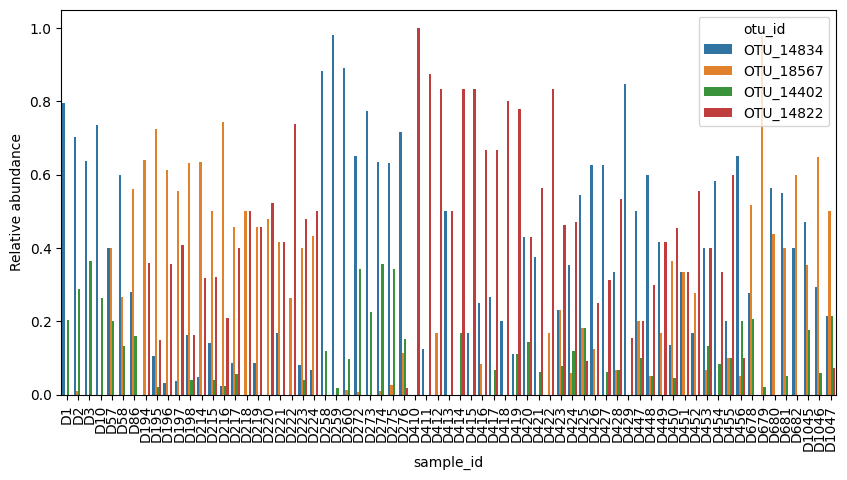

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(data=dat_subset,
            x="sample_id",
            y="rel_abundance",
            hue="otu_id")

plt.xticks(rotation=90)
plt.ylabel("Relative abundance")
plt.show()

**Reading the figure:** samples with taller bars for one color indicate that the corresponding OTU is relatively more abundant in those samples.

## Stack the bars

A stacked bar plot is often easier to read when the goal is to compare composition across samples.

This version summarizes each sample as a single bar while still showing how the OTUs contribute to the total community.

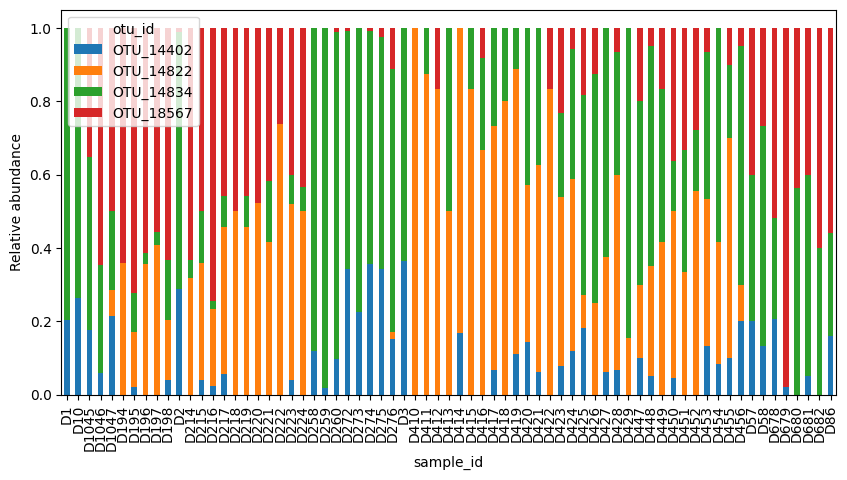

In [ ]:
pivot = dat_subset.pivot_table(index="sample_id",
                              columns="otu_id",
                              values="rel_abundance",
                              fill_value=0)

ax = pivot.plot(kind="bar", stacked=True, figsize=(10,5))
ax.set_ylabel("Relative abundance")
ax.set_xlabel("Sample")
plt.xticks(rotation=90)
plt.title("Stacked relative abundance by OTU")
plt.tight_layout()
plt.show()

**Why use the stacked version:** it compresses the information into one bar per sample while still preserving the composition of the selected OTUs.

# Part 2: Add sample metadata

So far, the data only include abundance information. Next, we add sample metadata so we can compare communities across experimental factors such as fraction or soil type.

In [ ]:
meta = pd.read_csv("/content/drive/MyDrive/ColabNotebooks/scip_data/Chapter5/sample_metadata.tsv", sep="\t")

meta.head()

,sample_id,soil,accession,fraction
0,D1,M21,Col-0,E
1,D2,M21,Col-0,E
2,D3,M21,Col-0,E
3,D10,M21,Ler-0,E
4,D57,C21,Col-0,E


## Merge metadata

Merging the metadata attaches experimental variables to each OTU-sample observation.

This step is important because it lets us group or facet the same abundance data by biological condition rather than by sample ID alone.

In [ ]:
dat_meta = dat_subset.merge(meta, on="sample_id")

dat_meta.head()

,otu_id,sample_id,count,rel_abundance,soil,accession,fraction
0,OTU_14834,D1,39,0.795918,M21,Col-0,E
1,OTU_18567,D1,0,0.000000,M21,Col-0,E
2,OTU_14402,D1,10,0.204082,M21,Col-0,E
3,OTU_14822,D1,0,0.000000,M21,Col-0,E
4,OTU_14834,D2,66,0.702128,M21,Col-0,E


**After the merge:** the abundance values are now paired with metadata such as fraction and soil, which makes group-wise comparisons possible.

## Faceted plots

Faceting creates one panel per metadata category, which is useful when you want to compare the same abundance pattern across groups.

Here, the panels help us see whether the selected OTUs behave differently across fractions.

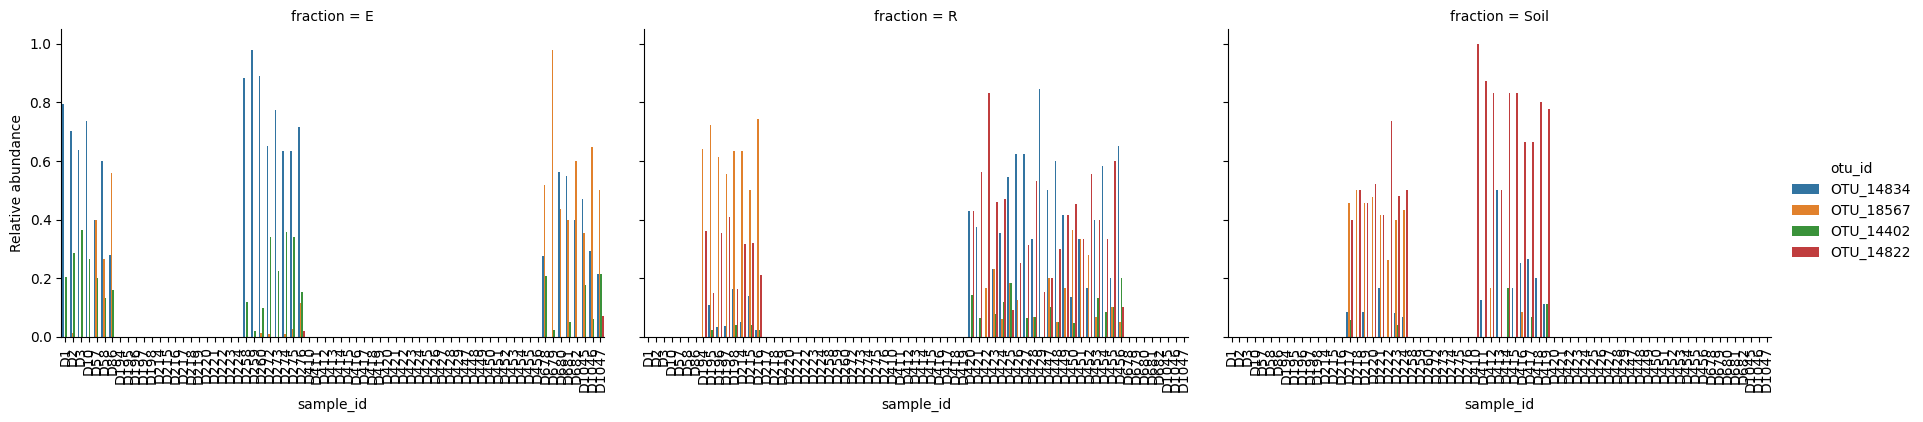

In [ ]:
g = sns.catplot(data=dat_meta,
                x="sample_id",
                y="rel_abundance",
                hue="otu_id",
                col="fraction",
                kind="bar",
                height=4,
                aspect=1.5)

g.set_xticklabels(rotation=90)
g.set_ylabels("Relative abundance")
g.set_axis_labels("Sample", "Relative abundance")
g.fig.suptitle("Relative abundance by fraction", y=1.03)

**Faceting summary:** each panel corresponds to one fraction, making it easy to compare the same OTUs across conditions.

## Combine multiple variables

Sometimes a single metadata column is not enough to capture the comparison you want. In that case, combining two variables into one facet label can make the plot easier to interpret.

Here we create a new label that combines fraction and soil type.

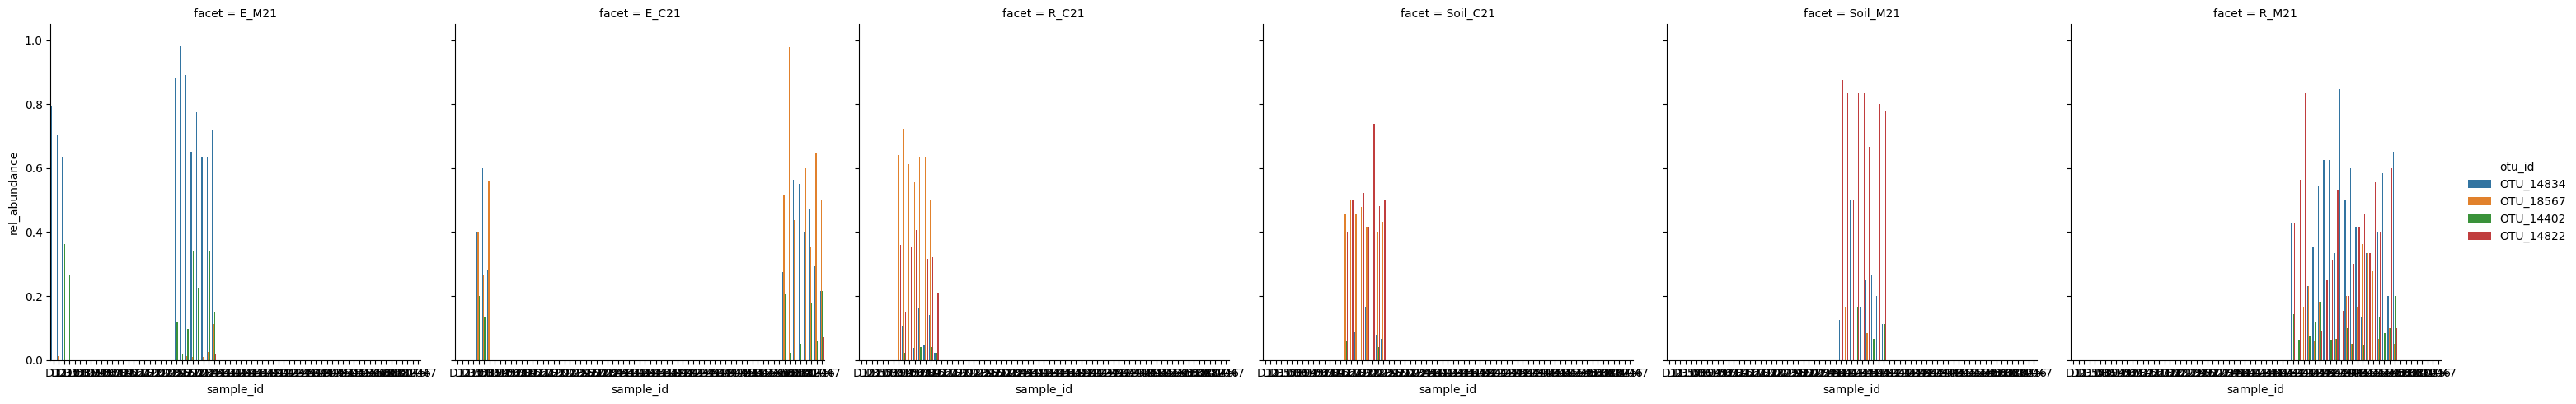

In [ ]:
dat_meta["facet"] = dat_meta["fraction"] + "_" + dat_meta["soil"]

g = sns.catplot(data=dat_meta,
                x="sample_id",
                y="rel_abundance",
                hue="otu_id",
                col="facet",
                kind="bar",
                height=4,
                aspect=1.2)

g.set_xticklabels(rotation=90)
g.set_ylabels("Relative abundance")
g.set_axis_labels("Sample", "Relative abundance")
g.fig.suptitle("Relative abundance by combined fraction and soil label", y=1.03)

**Combined labels:** a custom facet label is useful when the comparison depends on more than one experimental variable.

## Add taxonomy data

Instead of focusing on only a few OTUs, we can also summarize the community at a higher taxonomic level.

Adding taxonomy makes it possible to ask broader questions such as which phyla dominate each sample.

In [ ]:
tax = pd.read_csv("/content/drive/MyDrive/ColabNotebooks/SCIP2026/UPDATED CURRICULUM/Python Track/Python2026/scip_data/Chapter5/MicrobiologyData/otu_taxonomy.tsv", sep="\t")

tax.head()

,otu_id,Phylum
0,OTU_14834,Actinobacteria
1,OTU_18567,Proteobacteria
2,OTU_14402,Actinobacteria
3,OTU_14822,Proteobacteria
4,OTU_16757,Bacteroidetes


## Merge taxonomy

This merge links each OTU to its taxonomic assignment.

Once the taxonomy is attached, we can aggregate by phylum and compare broader community structure across samples.

In [ ]:
dat_full = dat.merge(tax, on="otu_id")

dat_full.head()

,otu_id,sample_id,count,Phylum
0,OTU_14834,D1,39,Actinobacteria
1,OTU_18567,D1,0,Proteobacteria
2,OTU_14402,D1,10,Actinobacteria
3,OTU_14822,D1,0,Proteobacteria
4,OTU_16757,D1,0,Bacteroidetes


**Taxonomy merge result:** the OTU table now carries phylum annotations, so abundance can be summarized at a higher taxonomic rank.

## Plot by phylum

Now we collapse the data to the phylum level and plot the relative abundance for each sample.

This view is less detailed than the OTU-level plot, but it is often much easier to interpret biologically.

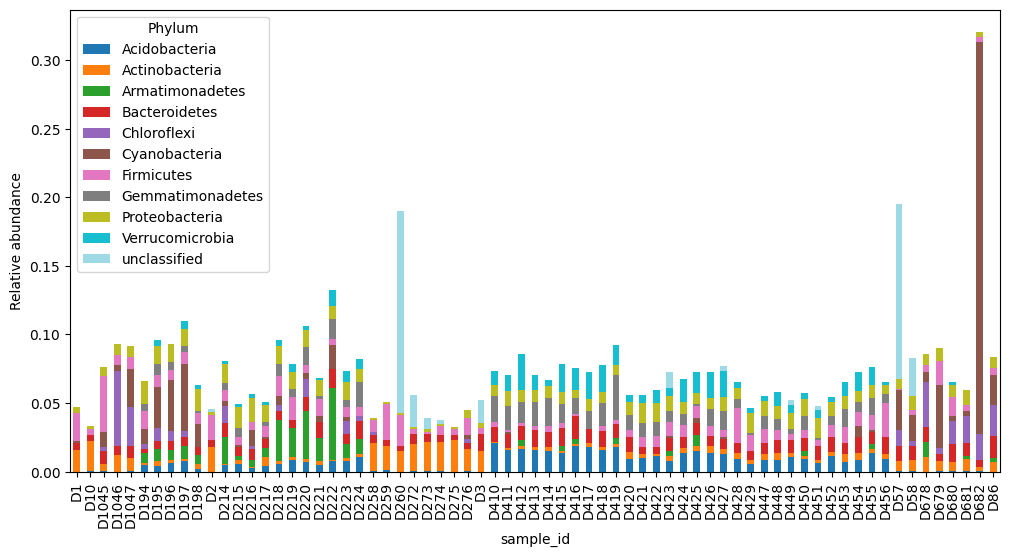

In [ ]:
dat_full["rel_abundance"] = dat_full.groupby("sample_id")["count"]\
                                    .transform(lambda x: x / x.sum())

pivot_phy = dat_full.pivot_table(index="sample_id",
                                columns="Phylum",
                                values="rel_abundance",
                                fill_value=0)

ax = pivot_phy.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab20")
ax.set_ylabel("Relative abundance")
ax.set_xlabel("Sample")
plt.xticks(rotation=90)
plt.title("Relative abundance by phylum")
plt.tight_layout()
plt.show()

**What this plot shows:** instead of individual OTUs, the community is now summarized by phylum, which usually gives a cleaner overview of the microbiome structure.

## Improve the colors

Different color palettes can make stacked bar plots easier to read.

The goal here is not just to make the figure look nicer, but also to make the phylum structure more distinguishable across samples.

<Axes: xlabel='sample_id'>

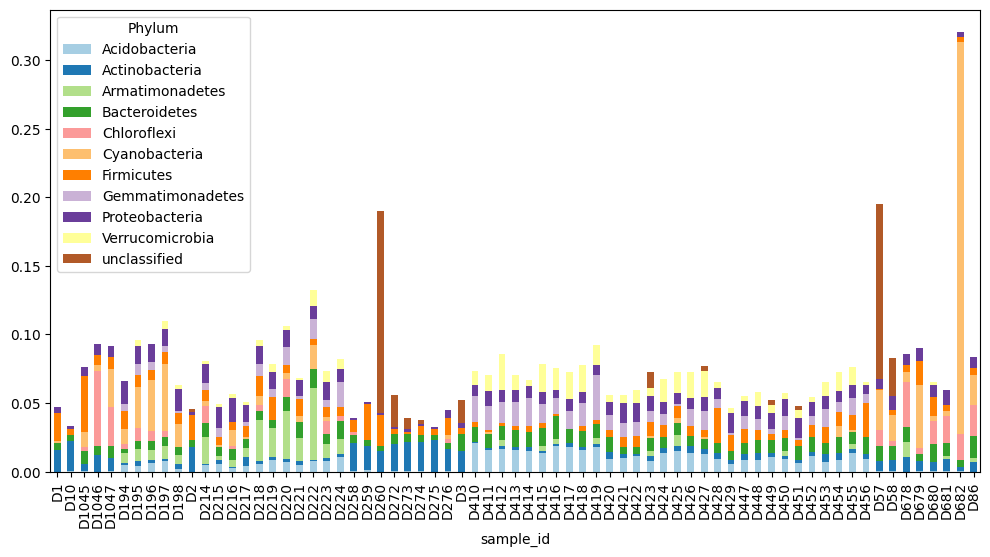

In [ ]:
ax = pivot_phy.plot(kind="bar",
               stacked=True,
               figsize=(12,6),
               colormap="Paired")
ax.set_ylabel("Relative abundance")
ax.set_xlabel("Sample")
plt.xticks(rotation=90)
plt.title("Relative abundance by phylum with a different palette")
plt.tight_layout()
plt.show()

**Palette comparison:** changing palettes does not change the data, but it can improve readability and help separate adjacent categories.

## Order phyla by abundance

Ordering categories by their average abundance helps the eye follow the most important phyla first.

This is especially useful in stacked bar plots, where the category order has a strong effect on readability.

In [ ]:
mean_freqs = (
    dat_full.groupby(["sample_id", "Phylum"])["count"].sum()
    .groupby(level=0)
    .transform(lambda x: x / x.sum())
    .reset_index(name="freq")
    .groupby("Phylum")["freq"].mean()
    .sort_values(ascending=False)
)

phyla_order = mean_freqs.index.tolist()

# Reorder the categorical levels so the plot follows abundance order.
dat_full["Phylum"] = pd.Categorical(dat_full["Phylum"],
                                    categories=phyla_order,
                                    ordered=True)

/tmp/ipykernel_1372/560751193.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_phy = dat_full.pivot_table(index="sample_id",


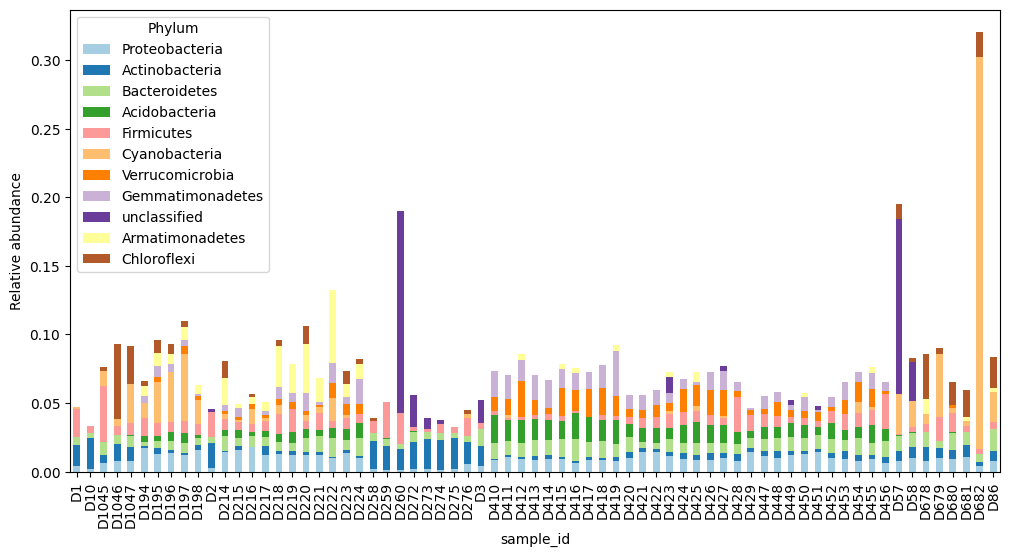

In [ ]:
pivot_phy = dat_full.pivot_table(index="sample_id",
                                columns="Phylum",
                                values="rel_abundance",
                                fill_value=0)

pivot_phy = pivot_phy[phyla_order]

ax = pivot_phy.plot(kind="bar", stacked=True, figsize=(12,6), colormap="Paired")
ax.set_ylabel("Relative abundance")
ax.set_xlabel("Sample")
plt.xticks(rotation=90)
plt.title("Phylum abundance ordered by mean frequency")
plt.tight_layout()
plt.show()

**Ordered view:** sorting phyla by mean abundance makes the major groups stand out first and tends to make the stacked bar plot easier to scan.

## Save the figure

The final step is to export the plot as a high-resolution image so it can be reused in a report, presentation, or manuscript.

Saving a clean version is often better than taking a screenshot because it preserves resolution and layout.

<Figure size 1200x600 with 0 Axes>

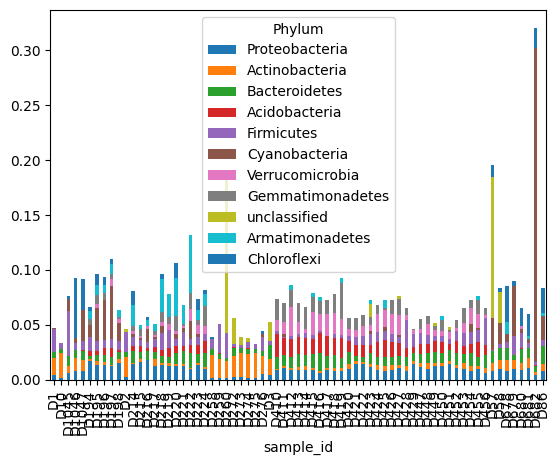

In [ ]:
plt.figure(figsize=(12,6))
ax = pivot_phy.plot(kind="bar", stacked=True)

ax.set_ylabel("Relative abundance")
ax.set_xlabel("Sample")
plt.xticks(rotation=90)
plt.title("Ordered phylum plot ready for export")
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/ColabNotebooks/SCIP2026/UPDATED CURRICULUM/Python Track/Python2026/scip_data/Chapter5/MicrobiologyData/rhizo_phylo_distribution.png", dpi=300, bbox_inches="tight")
plt.close()

## Reflection: Review

Go back through today’s exercises and identify Python syntax, functions, or code patterns that are still unfamiliar to you.

Write down at least three items and define them in your own words.

| Syntax / Function | What does it do? | Example from today’s notebook |
|---|---|---|
|  |  |  |
|  |  |  |
|  |  |  |

**Guiding questions**
- Which lines of code were hardest to understand?
- Which new Python functions or methods did you use today?
- Can you explain what each one does in your own words?